# **Task 1: Data Understanding and Visualization:**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/FruitinAmazon.zip'
extract_path = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")
print("Folders found:", os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully
Folders found: ['2408611_RachinShrestha_Workshop_5.ipynb', 'FruitinAmazon.zip', 'FruitinAmazon', 'saved_model']


Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


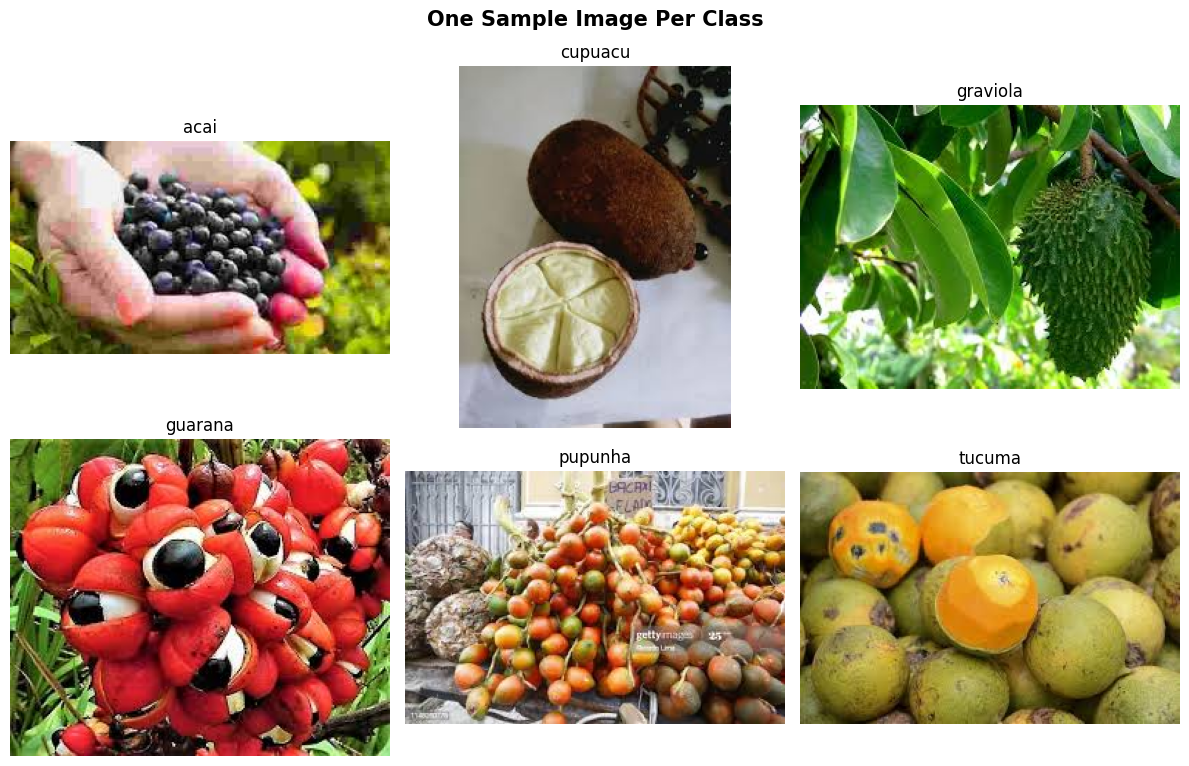

In [13]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/FruitinAmazon/train'

class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print(f"Classes found ({len(class_dirs)}): {class_dirs}")

selected_images = []
selected_labels = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        chosen = random.choice(images)
        selected_images.append(os.path.join(cls_path, chosen))
        selected_labels.append(cls)

num_images = len(selected_images)
cols = (num_images + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(selected_images, selected_labels)):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=12)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("One Sample Image Per Class", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
from PIL import Image

corrupted_images = []

print("Checking for corrupted images in train directory\n")

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        image_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(image_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No corrupted images found")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

Checking for corrupted images in train directory

No corrupted images found


# **Task 2: Loading and Preprocessing Image Data in keras:**

In [15]:
import tensorflow as tf

img_height = 128
img_width  = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

class_names = train_ds.class_names

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

num_classes = len(class_names)

print(f"\nData loaded successfully")
print(f"Classes ({num_classes}): {class_names}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

Data loaded successfully
Classes (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# **Task 3 - Implement a CNN with**

In [16]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=(1, 1),
        activation='relu',
        input_shape=(img_height, img_width, 3)
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=(1, 1),
        activation='relu'
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

# **Task 4: Compile the Model**

In [17]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


# **Task 4: Train the Model**

In [18]:
# Train the model with callbacks

import os

# Create a folder to save the best model
os.makedirs('/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model', exist_ok=True)


# ModelCheckpoint: saves the best model during training
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5',
    monitor='val_accuracy',    # Watch validation accuracy
    save_best_only=True,       # Only save when it improves
    verbose=1
)

# EarlyStopping: stops training if val_accuracy stops improving
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

print("\nTraining complete")

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.0845 - loss: 1.8455
Epoch 1: val_accuracy improved from None to 0.11111, saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.0972 - loss: 1.8933 - val_accuracy: 0.1111 - val_loss: 2.2821
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.4323 - loss: 1.6570
Epoch 2: val_accuracy improved from 0.11111 to 0.55556, saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 600ms/step - accuracy: 0.3750 - loss: 1.6919 - val_accuracy: 0.5556 - val_loss: 1.3391
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.4091 - loss: 1.4094
Epoch 3: val_accuracy improved from 0.55556 to 0.72222, saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 615ms/step - accuracy: 0.4306 - loss: 1.3508 - val_accuracy: 0.7222 - val_loss: 1.3651
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.5486 - loss: 1.2299
Epoch 4: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 0.5833 - loss: 1.1661 - val_accuracy: 0.7222 - val_loss: 1.0865
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.8003 - loss: 0.8526
Epoch 5: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 563ms/step - accuracy: 0.7917 - loss: 0.8669 - val_accuracy: 0.7222 - val_loss: 0.8269
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.7760 - loss: 0.7201
Epoch 6: val_accuracy improved from 0.72222 to 0.88889, saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/bes


Epoch 6: finished saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7500 - loss: 0.7086 - val_accuracy: 0.8889 - val_loss: 0.6945
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9155 - loss: 0.5270
Epoch 7: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.9028 - loss: 0.5364 - val_accuracy: 0.8333 - val_loss: 0.7563
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9497 - loss: 0.4132
Epoch 8: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 598ms/step - accuracy: 0.9583 - loss: 0.3698 - val_accuracy: 0.8333 - val_loss: 0.5512
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9601 - loss: 0.2563
Epoch 9: val_accuracy improved from 0.88889 to 0.94444, saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_m


Epoch 9: finished saving model to /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 583ms/step - accuracy: 0.9583 - loss: 0.2836 - val_accuracy: 0.9444 - val_loss: 0.3747
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 1.0000 - loss: 0.1377
Epoch 10: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 1.0000 - loss: 0.1341 - val_accuracy: 0.7778 - val_loss: 0.7929
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9902 - loss: 0.1680
Epoch 11: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - accuracy: 0.9861 - loss: 0.1595 - val_accuracy: 0.8333 - val_loss: 0.4960
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 1.0000 - loss: 0.0499
Epoch 12: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 814ms/step - accuracy: 1.0000 - loss: 0.0440 - val_accuracy: 0.8889 - val_los

# **Task 5: Evaluate the Model**

In [19]:
test_loss, test_accuracy = model.evaluate(val_ds)

print(f"\nEvaluation Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9444 - loss: 0.3747

Evaluation Results:
Test Loss: 0.3747
Test Accuracy: 0.9444 (94.44%)


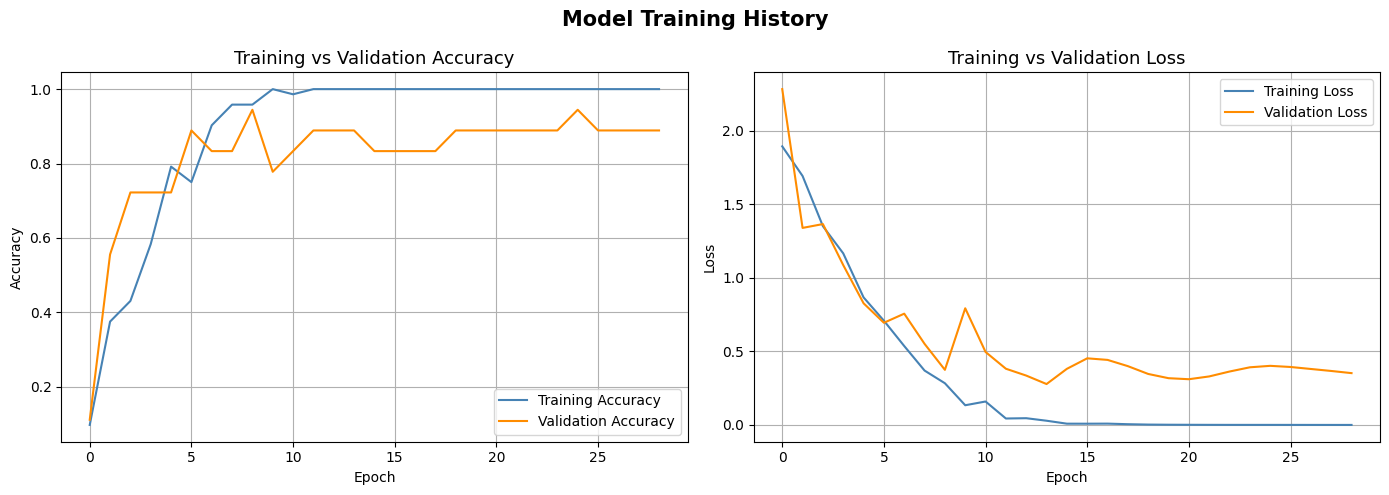

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(len(history.history['accuracy']))

axes[0].plot(epochs_range, history.history['accuracy'],     label='Training Accuracy',   color='steelblue')
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
axes[0].set_title('Training vs Validation Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history.history['loss'],     label='Training Loss',   color='steelblue')
axes[1].plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='darkorange')
axes[1].set_title('Training vs Validation Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# **Task 6: Save and Load the Model**

In [21]:
save_path = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/fruit_cnn_model.h5'
model.save(save_path)
print(f"Model saved to: {save_path}")

loaded_model = tf.keras.models.load_model(save_path)
print("Model loaded successfully")

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model Evaluation:")
print(f"Test Loss: {loaded_loss:.4f}")
print(f"Test Accuracy: {loaded_accuracy:.4f} ({loaded_accuracy * 100:.2f}%)")

Model saved to: /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 5/saved_model/fruit_cnn_model.h5
Model loaded successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step - accuracy: 0.9444 - loss: 0.3747

Loaded Model Evaluation:
Test Loss: 0.3747
Test Accuracy: 0.9444 (94.44%)


# **Task 7: Predictions and Classification Report**

In [22]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))

Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       0.94      1.00      0.97        15

    accuracy                           0.94        18
   macro avg       0.32      0.28      0.29        18
weighted avg       0.95      0.94      0.94        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me